In [2]:
!pip install opendatasets --quiet

import torch
from torch import nn
from torch.optim import Adam
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [3]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: syaika123
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:44<00:00, 16.5MB/s]


In [4]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
    for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
        for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
            image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
            labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "labels"])
print(data_df["labels"].value_counts())
print("Total data:", len(data_df))

labels
cat     5653
dog     5239
wild    5238
Name: count, dtype: int64
Total data: 16130


In [5]:
# PERBAIKAN 1: Split lebih seimbang 70/20/10
train = data_df.sample(frac=0.7, random_state=42)
remaining = data_df.drop(train.index)

val = remaining.sample(frac=0.67, random_state=42)  # ~20% dari total
test = remaining.drop(val.index)                     # ~10% dari total

print(f"Train: {train.shape[0]} | Val: {val.shape[0]} | Test: {test.shape[0]}")

Train: 11291 | Val: 3242 | Test: 1597


In [6]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

# PERBAIKAN 2: Tambah augmentasi di training
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),        # Flip acak
    transforms.RandomRotation(15),            # Rotasi acak
    transforms.ColorJitter(brightness=0.3,    # Variasi warna
                          contrast=0.3,
                          saturation=0.3),
    transforms.RandomAffine(degrees=0,        # Geser acak
                           translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                        std=[0.5, 0.5, 0.5])
])

# Validasi & test TIDAK di-augment
val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                        std=[0.5, 0.5, 0.5])
])

In [7]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.labels = torch.tensor(
            label_encoder.transform(dataframe['labels'])
        ).to(device)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image).to(device)
        return image, label

train_dataset = CustomImageDataset(train, transform=train_transform)
val_dataset   = CustomImageDataset(val,   transform=val_transform)
test_dataset  = CustomImageDataset(test,  transform=val_transform)

In [8]:
# PERBAIKAN 3: Batch size lebih besar = lebih stabil
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 353
Val batches: 102


In [9]:
# PERBAIKAN 4: Tambah Dropout + BatchNorm
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)      # Baru: stabilkan training

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pooling = nn.MaxPool2d(2, 2)
        self.relu    = nn.ReLU()
        self.flatten = nn.Flatten()

        self.dropout1 = nn.Dropout(0.5)      # Baru: cegah overfitting
        self.linear   = nn.Linear(128*16*16, 256)
        self.bn4      = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.3)      # Baru
        self.output   = nn.Linear(256, len(data_df['labels'].unique()))

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pooling(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pooling(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pooling(x)

        x = self.flatten(x)
        x = self.dropout1(x)
        x = self.relu(self.bn4(self.linear(x)))
        x = self.dropout2(x)
        x = self.output(x)

        return x

model = Net().to(device)
print(model)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.5, inplace=False)
  (linear): Linear(in_features=32768, out_features=256, bias=True)
  (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=256, out_features=3, bias=True)
)


In [10]:
# PERBAIKAN 5: Tambah scheduler + early stopping
LR = 1e-4
EPOCHS = 30

criterion  = nn.CrossEntropyLoss()
optimizer  = Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Scheduler: kurangi LR jika val_loss tidak turun
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Early stopping
best_val_loss    = float('inf')
best_model_wts   = copy.deepcopy(model.state_dict())
patience         = 7
patience_counter = 0

total_loss_train_plot = []
total_loss_val_plot   = []
total_acc_train_plot  = []
total_acc_val_plot    = []

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_loss_train = 0
    total_acc_train  = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()
        total_acc_train  += (torch.argmax(outputs, axis=1) == labels).sum().item()

    # --- VALIDASI ---
    model.eval()
    total_loss_val = 0
    total_acc_val  = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            total_loss_val += loss.item()
            total_acc_val  += (torch.argmax(outputs, axis=1) == labels).sum().item()

    # Hitung rata-rata
    avg_train_loss = total_loss_train / len(train_loader)
    avg_val_loss   = total_loss_val   / len(val_loader)
    avg_train_acc  = (total_acc_train / len(train_dataset)) * 100
    avg_val_acc    = (total_acc_val   / len(val_dataset))   * 100

    total_loss_train_plot.append(avg_train_loss)
    total_loss_val_plot.append(avg_val_loss)
    total_acc_train_plot.append(avg_train_acc)
    total_acc_val_plot.append(avg_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.2f}%")

    # Scheduler step
    scheduler.step(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss  = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("  ✅ Model terbaik disimpan!")
    else:
        patience_counter += 1
        print(f"  ⏳ Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("⛔ Early stopping!")
            break

model.load_state_dict(best_model_wts)
print("\nTraining selesai! Model terbaik dimuat.")

Epoch 1/30 | Train Loss: 0.5180 Acc: 78.94% | Val Loss: 0.1926 Acc: 93.89%
  ✅ Model terbaik disimpan!
Epoch 2/30 | Train Loss: 0.3177 Acc: 87.93% | Val Loss: 0.1280 Acc: 95.68%
  ✅ Model terbaik disimpan!
Epoch 3/30 | Train Loss: 0.2609 Acc: 90.37% | Val Loss: 0.1091 Acc: 96.58%
  ✅ Model terbaik disimpan!
Epoch 4/30 | Train Loss: 0.2310 Acc: 91.31% | Val Loss: 0.0975 Acc: 96.76%
  ✅ Model terbaik disimpan!
Epoch 5/30 | Train Loss: 0.2124 Acc: 92.12% | Val Loss: 0.1248 Acc: 95.25%
  ⏳ Patience: 1/7
Epoch 6/30 | Train Loss: 0.1957 Acc: 92.80% | Val Loss: 0.0755 Acc: 97.87%
  ✅ Model terbaik disimpan!
Epoch 7/30 | Train Loss: 0.1815 Acc: 93.36% | Val Loss: 0.1358 Acc: 94.91%
  ⏳ Patience: 1/7
Epoch 8/30 | Train Loss: 0.1787 Acc: 93.76% | Val Loss: 0.0791 Acc: 97.47%
  ⏳ Patience: 2/7
Epoch 9/30 | Train Loss: 0.1612 Acc: 94.23% | Val Loss: 0.0897 Acc: 96.58%
  ⏳ Patience: 3/7
Epoch 10/30 | Train Loss: 0.1572 Acc: 94.37% | Val Loss: 0.0818 Acc: 97.01%
  ⏳ Patience: 4/7
Epoch 11/30 | Train

Test Accuracy: 98.43% | Test Loss: 0.0508


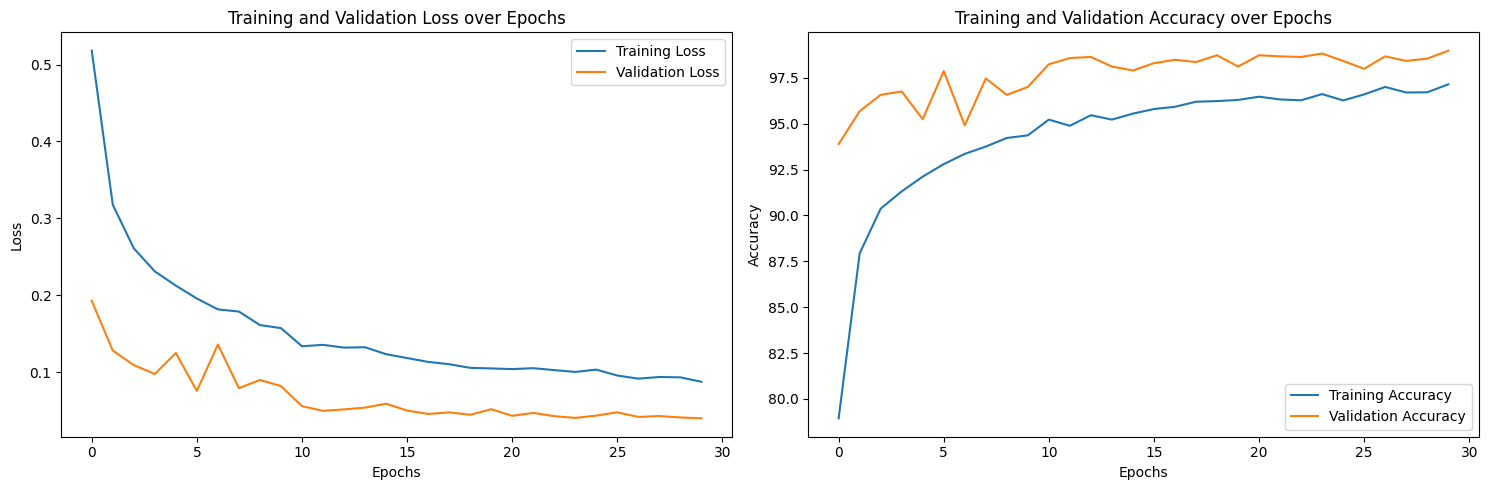

In [11]:
# Test
model.eval()
total_acc_test = 0
total_loss_test = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        total_loss_test += loss.item()
        total_acc_test  += (torch.argmax(outputs, axis=1) == labels).sum().item()

test_acc  = (total_acc_test / len(test_dataset)) * 100
test_loss = total_loss_test / len(test_loader)
print(f"Test Accuracy: {test_acc:.2f}% | Test Loss: {test_loss:.4f}")

# Grafik
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot,   label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_val_plot,   label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.savefig("hasil_grafik.png")
plt.show()

In [12]:
torch.save(model.state_dict(), "animal_classifier_optimized.pth")
print("Model tersimpan!")

Model tersimpan!


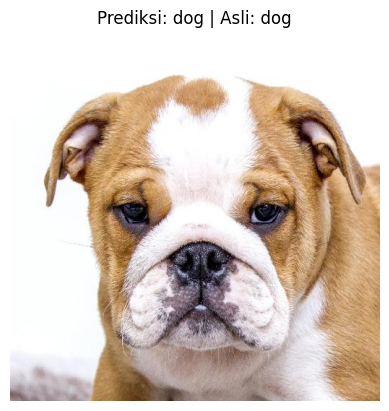

Prediksi: dog
Label asli: dog
Benar: True


In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Ambil 1 gambar random dari dataset
sample = data_df.sample(n=1).iloc[0]
img_path = sample['image_path']
true_label = sample['labels']

# Prediksi
image = Image.open(img_path).convert('RGB')
img_tensor = val_transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    predicted = torch.argmax(output, axis=1).item()
    predicted_label = label_encoder.inverse_transform([predicted])[0]

# Tampilkan
plt.imshow(image)
plt.title(f"Prediksi: {predicted_label} | Asli: {true_label}")
plt.axis('off')
plt.show()

print(f"Prediksi: {predicted_label}")
print(f"Label asli: {true_label}")
print(f"Benar: {predicted_label == true_label}")

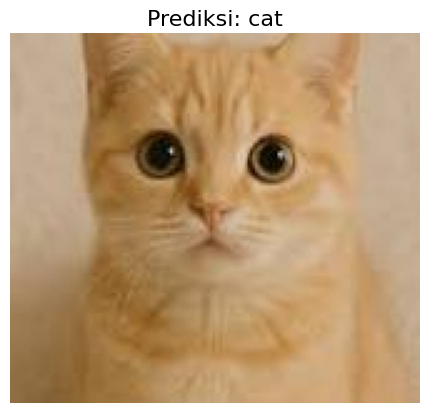

Hasil Prediksi: cat


In [15]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Ganti nama file sesuai yang kamu upload
img_path = "kucing.jpg"

# Buka & prediksi
image = Image.open(img_path).convert('RGB')
img_tensor = val_transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    predicted = torch.argmax(output, axis=1).item()
    predicted_label = label_encoder.inverse_transform([predicted])[0]

# Tampilkan
plt.imshow(image)
plt.title(f"Prediksi: {predicted_label}", fontsize=16)
plt.axis('off')
plt.show()

print(f"Hasil Prediksi: {predicted_label}")